## Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel('data.xlsx')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [3]:
df.shape

(45593, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  object 
 9   Type_of_vehicle              45593 non-null  object 
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


## Data Cleaning

In [5]:
df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Type_of_order                  0
Type_of_vehicle                0
Time_taken(min)                0
dtype: int64

In [6]:
# Checking for Duplicate values
df.duplicated().sum()

np.int64(0)

In [7]:
# Checking for unique values
df.nunique()

ID                             45355
Delivery_person_ID              1320
Delivery_person_Age               22
Delivery_person_Ratings           28
Restaurant_latitude              657
Restaurant_longitude             518
Delivery_location_latitude      4373
Delivery_location_longitude     4373
Type_of_order                      4
Type_of_vehicle                    4
Time_taken(min)                   45
dtype: int64

In [9]:
df['Delivery_person_Ratings'].value_counts()

Delivery_person_Ratings
4.6    8848
4.8    7148
4.7    7142
4.9    7041
5.0    3996
4.5    3303
4.1    1430
4.2    1418
4.3    1409
4.4    1361
4.0    1077
3.5     249
3.8     228
3.7     225
3.6     207
3.9     197
6.0      53
1.0      38
3.4      32
3.1      29
3.2      29
3.3      25
2.6      22
2.7      22
2.5      20
2.8      19
2.9      19
3.0       6
Name: count, dtype: int64

In [10]:
# Few points have ratings greater than 5.
df['Delivery_person_Ratings']=df['Delivery_person_Ratings'].clip(upper=5)

In [11]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.631204,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.324613,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,5.000000,30.914057,88.433452,31.054057,88.563452,54.000000


## EDA

### Calculating the distance 

In [12]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # earth radius km
    dLat = np.radians(lat2-lat1)
    dLon = np.radians(lon2-lon1)
    a = np.sin(dLat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dLon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return R*c
df["distance_km"] = haversine(
   df["Restaurant_latitude"],
   df["Restaurant_longitude"],
   df["Delivery_location_latitude"],
   df["Delivery_location_longitude"]
)

In [13]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min),distance_km
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.631204,17.017729,70.231332,17.465186,70.845702,26.294607,99.303911
std,5.696793,0.324613,8.185109,22.883647,7.335122,21.118812,9.383806,1099.731281
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000,1.465067
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000,4.663493
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000,9.264281
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000,13.763977
max,50.000000,5.000000,30.914057,88.433452,31.054057,88.563452,54.000000,19692.674606


<Axes: >

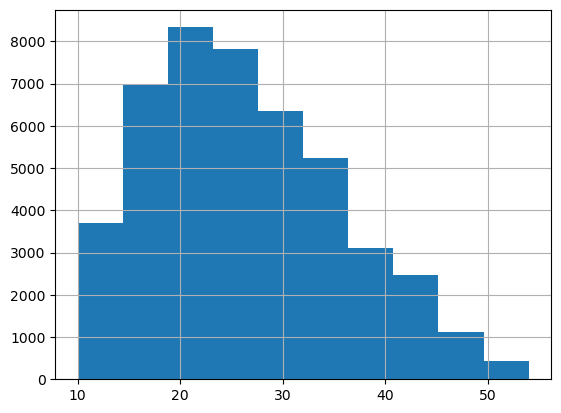

In [14]:
df['Time_taken(min)'].hist()

In [15]:
q1 = df["Time_taken(min)"].quantile(0.25)
q3 = df["Time_taken(min)"].quantile(0.75)
iqr = q3 - q1
df = df[(df["Time_taken(min)"] >= q1 - 1.5*iqr) & (df["Time_taken(min)"] <= q3 + 1.5*iqr)]

<Axes: >

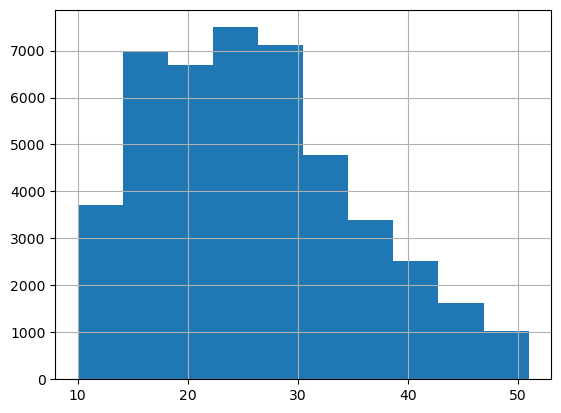

In [16]:
df['Time_taken(min)'].hist()

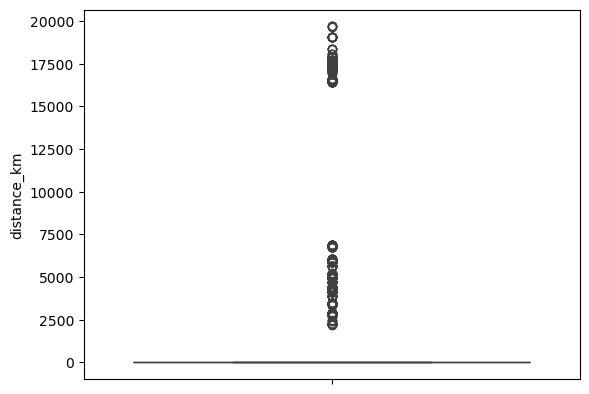

In [17]:
sns.boxplot(df['distance_km'])
plt.show()

In [18]:
df = df[df['distance_km']<=50]

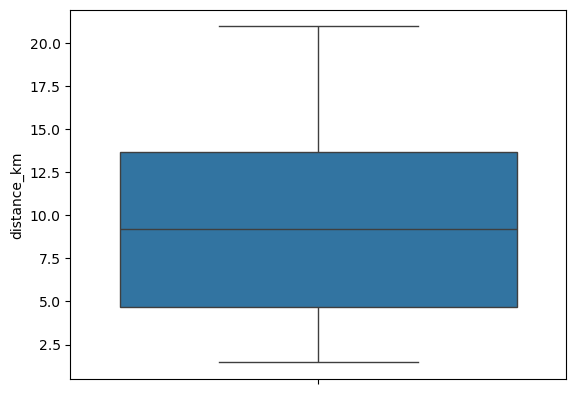

In [19]:
sns.boxplot(df['distance_km'])
plt.show()

In [20]:
df=df [(df['Delivery_person_Age']>=18)&(df['Delivery_person_Age']<=40)]

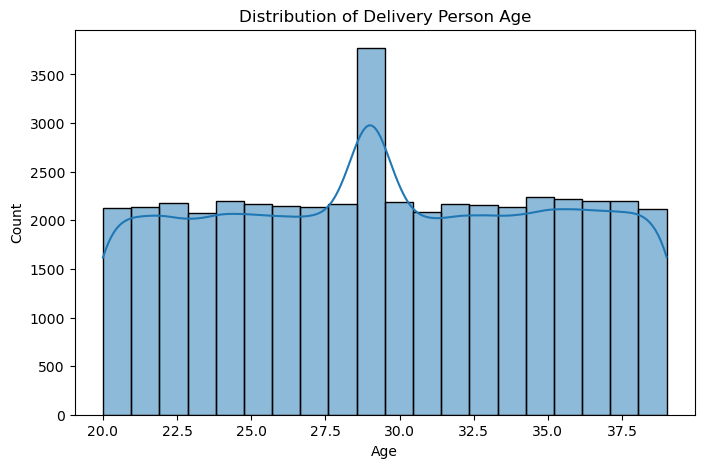

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Delivery_person_Age'], bins=20, kde=True)
plt.title("Distribution of Delivery Person Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='distance_km', ylabel='Time_taken(min)'>

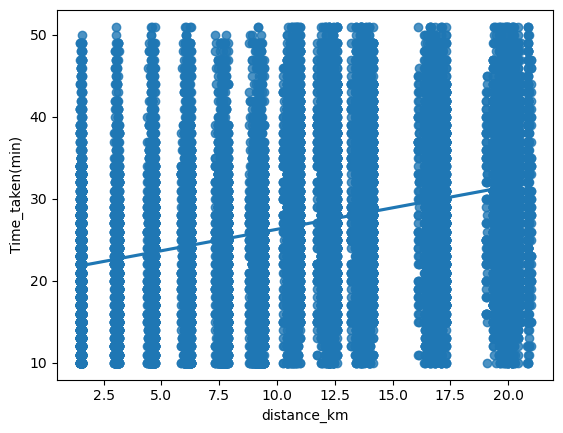

In [22]:
sns.regplot(x=df['distance_km'], y=df['Time_taken(min)'])

Text(0.5, 1.0, 'Delivery Time Distribution')

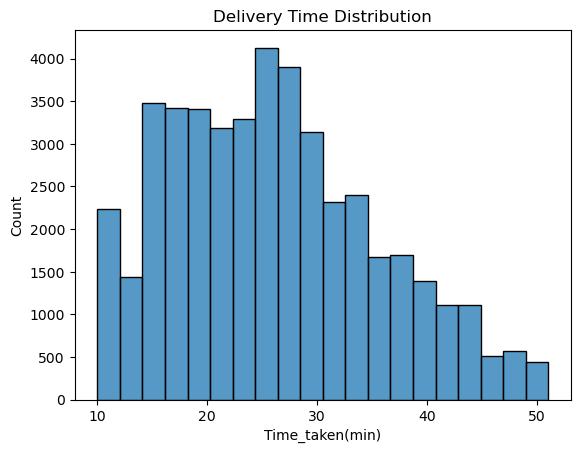

In [23]:
sns.histplot(df['Time_taken(min)'], bins=20)
plt.title("Delivery Time Distribution")

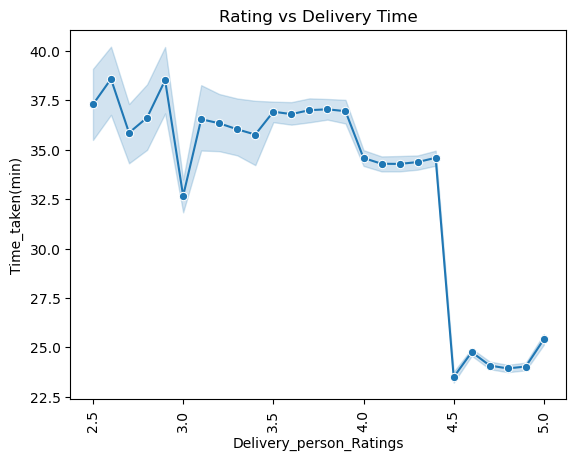

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(x=df['Delivery_person_Ratings'], y=df['Time_taken(min)'],marker='o')
plt.title("Rating vs Delivery Time")
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='Type_of_order', ylabel='Time_taken(min)'>

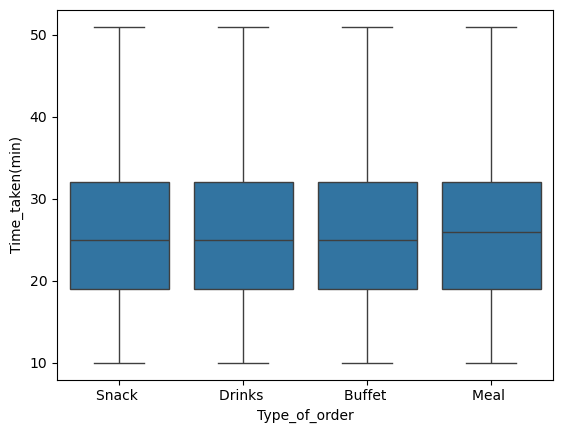

In [25]:
sns.boxplot(x="Type_of_order", y="Time_taken(min)", data=df)

<Axes: xlabel='Type_of_vehicle', ylabel='Time_taken(min)'>

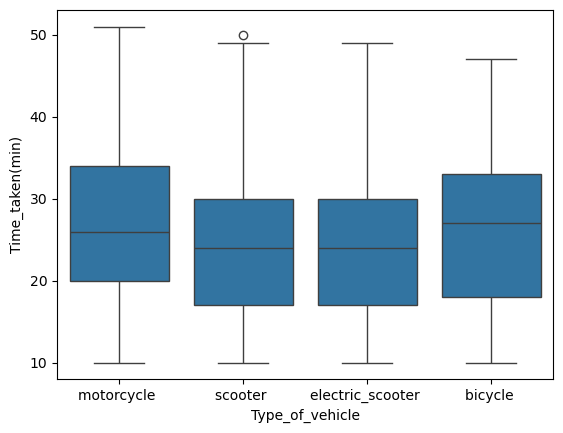

In [26]:
sns.boxplot(x="Type_of_vehicle", y="Time_taken(min)", data=df)

### Extracting New Features and Dropping Unimportant Features

In [27]:
df=df.drop('ID',axis=1)

In [28]:
df["city"] = df["Delivery_person_ID"].str.extract(r"([a-zA-Z]+)res", flags=re.IGNORECASE)

In [29]:
df['Type_of_vehicle'] = df['Type_of_vehicle'].str.strip().str.lower()

In [30]:
vehicle_speeds = {
   'motorcycle': 40,   
   'scooter': 38,
   'bicycle': 10,
   'electric_scooter': 37
}
df['avg_speed'] = df['Type_of_vehicle'].map(vehicle_speeds)

In [31]:
df['travel_time'] = (df['distance_km'] / df['avg_speed']) * 60

In [32]:
df['cooking_time'] = (df['Time_taken(min)'] - df['travel_time']).clip(lower=0)

In [33]:
restaurant_stats = df.groupby(['city', 'Delivery_person_ID', 'Type_of_order']).agg(
   min_cooking_time=('cooking_time', 'min'),
   median_cooking_time=('cooking_time', 'median'),
   mean_cooking_time=('cooking_time', 'mean'),
   num_orders=('cooking_time', 'count')
).reset_index()

In [34]:
df = df.merge(restaurant_stats, on=["Delivery_person_ID",'city','Type_of_order'], how="left")

In [35]:
df=df.drop(['Delivery_person_ID','city','Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude','travel_time','cooking_time','avg_speed'],axis=1)

<Axes: >

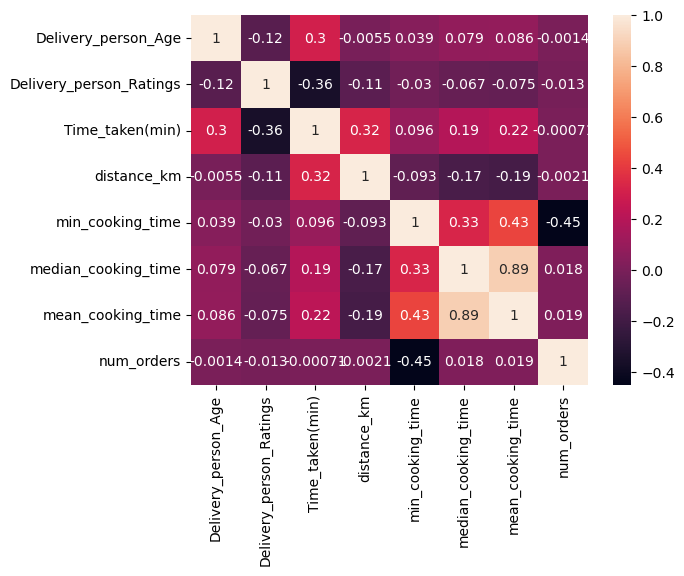

In [36]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Data Preprocessing

### Encoding

In [37]:
df = pd.get_dummies(df,columns=["Type_of_vehicle",'Type_of_order'],drop_first=True,dtype=int)

### Scaling

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [40]:
scaler

StandardScaler()

## Model Building

In [42]:
from sklearn.model_selection import train_test_split
X = df.drop(["Time_taken(min)"], axis=1)
y = df["Time_taken(min)"]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [68]:
X.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km',
       'min_cooking_time', 'median_cooking_time', 'mean_cooking_time',
       'num_orders', 'Type_of_vehicle_electric_scooter',
       'Type_of_vehicle_motorcycle', 'Type_of_vehicle_scooter',
       'Type_of_order_Drinks ', 'Type_of_order_Meal ', 'Type_of_order_Snack '],
      dtype='object')

In [43]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Linear Regression

In [54]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr

LinearRegression()

In [55]:
lr.fit(X_train, y_train)
y_train_pred_lr = lr.predict(X_train)
y_pred_lr = lr.predict(X_test)

### Random Forest Regressor

In [56]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf

RandomForestRegressor(n_estimators=300, random_state=42)

In [57]:
rf.fit(X_train, y_train)
y_train_pred_rf = rf.predict(X_train)
y_pred_rf = rf.predict(X_test)

### SVM

In [65]:
from sklearn.svm import SVR
svm = SVR(kernel='rbf')
svm

SVR()

In [66]:
svm.fit(X_train_scaled, y_train)
y_train_pred_svm = svm.predict(X_train_scaled)
y_pred_svm = svm.predict(X_test_scaled)

### XGBoost Regressor

In [62]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
   n_estimators=500,
   learning_rate=0.05,
   max_depth=6,
   subsample=0.8,
   colsample_bytree=0.8,
   random_state=42
)
xgb

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [63]:
xgb.fit(X_train, y_train)
y_train_pred_xgb = xgb.predict(X_train) 
y_pred_xgb = xgb.predict(X_test)

In [67]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate(name, y_train, y_train_pred, y_test, y_test_pred):
    print(f"----- {name} -----")
    
    # TRAIN METRICS
    r2_train = r2_score(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    
    print("Train Metrics:")
    print(f"R2   : {r2_train:.4f}")
    print(f"MAE  : {mae_train:.4f}")
    print(f"MSE  : {mse_train:.4f}")
    print(f"RMSE : {rmse_train:.4f}")
    
    print()
    
    # TEST METRICS
    r2_test = r2_score(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    
    print("Test Metrics:")
    print(f"R2   : {r2_test:.4f}")
    print(f"MAE  : {mae_test:.4f}")
    print(f"MSE  : {mse_test:.4f}")
    print(f"RMSE : {rmse_test:.4f}")
    
    print("\n")


evaluate("Linear Regression", y_train, y_train_pred_lr, y_test, y_pred_lr)
evaluate("Random Forest Regressor", y_train, y_train_pred_rf, y_test, y_pred_rf)
evaluate("SVM", y_train, y_train_pred_svm, y_test, y_pred_svm)
evaluate("XGBoost Regressor", y_train, y_train_pred_xgb, y_test, y_pred_xgb)

----- Linear Regression -----
Train Metrics:
R2   : 0.3506
MAE  : 5.9016
MSE  : 54.5988
RMSE : 7.3891

Test Metrics:
R2   : 0.3527
MAE  : 5.9119
MSE  : 55.2652
RMSE : 7.4341


----- Random Forest Regressor -----
Train Metrics:
R2   : 0.9192
MAE  : 2.0185
MSE  : 6.7950
RMSE : 2.6067

Test Metrics:
R2   : 0.4082
MAE  : 5.4906
MSE  : 50.5253
RMSE : 7.1081


----- SVM -----
Train Metrics:
R2   : 0.4166
MAE  : 5.4262
MSE  : 49.0458
RMSE : 7.0033

Test Metrics:
R2   : 0.4008
MAE  : 5.5531
MSE  : 51.1545
RMSE : 7.1522


----- XGBoost Regressor -----
Train Metrics:
R2   : 0.5769
MAE  : 4.6529
MSE  : 35.5743
RMSE : 5.9644

Test Metrics:
R2   : 0.4490
MAE  : 5.3310
MSE  : 47.0416
RMSE : 6.8587




In [72]:
X.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km',
       'min_cooking_time', 'median_cooking_time', 'mean_cooking_time',
       'num_orders', 'Type_of_vehicle_electric_scooter',
       'Type_of_vehicle_motorcycle', 'Type_of_vehicle_scooter',
       'Type_of_order_Drinks ', 'Type_of_order_Meal ', 'Type_of_order_Snack '],
      dtype='object')

In [74]:
import pickle
with open("xgb.pkl", "wb") as f:
    pickle.dump(xgb, f)